In [58]:
from kan import KAN, create_dataset
from kan.feynman import get_feynman_dataset
import pandas as pd
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [59]:
# train_df = pd.read_csv("../../../resource/datasets/srsd-feynman_easy_csv/train/feynman-i.12.1.txt.csv", header=None)[:2000]
# test_df = pd.read_csv("../../../resource/datasets/srsd-feynman_easy_csv/train/feynman-i.12.1.txt.csv", header=None)[:2000]
# print(train_df.head())
# print(test_df.head())
# scaler = StandardScaler()
# train_df = scaler.fit_transform(train_df)
# test_df = scaler.transform(test_df)

# X_train = torch.tensor(train_df[:, :-1], dtype=torch.float32)
# y_train = torch.tensor(train_df[:, -1], dtype=torch.float32)
# X_test  = torch.tensor(test_df[:, :-1], dtype=torch.float32)
# y_test  = torch.tensor(test_df[:, -1], dtype=torch.float32)

# X_train = torch.tensor(train_df.iloc[:, :-1].to_numpy(), dtype=torch.float32)
# X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
# y_train = torch.tensor(train_df.iloc[:, -1].to_numpy(), dtype=torch.float32)
# X_test  = torch.tensor(test_df.iloc[:, :-1].to_numpy(), dtype=torch.float32)
# X_test  = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
# y_test  = torch.tensor(test_df.iloc[:, -1].to_numpy(), dtype=torch.float32)


# print("X_train NaNs:", torch.isnan(X_train).any())
# print("y_train NaNs:", torch.isnan(y_train).any())
# print("X_train Infs:", torch.isinf(X_train).any())

# dataset1 = {'train_input':X_train, 'train_label':y_train, 'test_input': X_test, 'test_label':y_test}

device = "cpu"

In [80]:
seed = 42
symbols, _, func, ranges = get_feynman_dataset("I.12.1")
dataset = create_dataset(func, n_var=len(symbols), normalize_input=True, seed=seed, train_num=2000, test_num=2000, ranges=ranges)

In [61]:
# x_np = X_train.detach().cpu().numpy() if isinstance(X_train, torch.Tensor) else np.asarray(X_train)
# y_np = y_train.detach().cpu().numpy() if isinstance(y_train, torch.Tensor) else np.asarray(y_train)

# if x_np.shape[1] != 2:
#     raise ValueError(f"Expected X_train with 2 columns, got shape {x_np.shape}")

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(x_np[:, 0], x_np[:, 1], y_np, s=10, alpha=0.7)
# ax.set_xlabel('X_train[:, 0]')
# ax.set_ylabel('X_train[:, 1]')
# ax.set_zlabel('y_train')
# ax.set_title('3D Scatter: X_train vs y_train')
# plt.tight_layout()
# plt.show()

In [62]:
# x_np = X_train.detach().cpu().numpy() if isinstance(X_train, torch.Tensor) else np.asarray(X_train)
# y_np = y_train.detach().cpu().numpy() if isinstance(y_train, torch.Tensor) else np.asarray(y_train)

# if x_np.shape[1] != 2:
#     raise ValueError(f"Expected X_train with 2 columns, got shape {x_np.shape}")

# plt.figure(figsize=(7, 6))
# heat = plt.tricontourf(x_np[:, 0], x_np[:, 1], y_np, levels=80, cmap='viridis')
# plt.scatter(x_np[:, 0], x_np[:, 1], s=5, c='black', alpha=0.35, edgecolors='none', label='datapoints')
# plt.colorbar(heat, label='y_train')
# plt.xlabel('X_train[:, 0]')
# plt.ylabel('X_train[:, 1]')
# plt.title('Top-Down Heat Map: y_train over X_train plane')
# plt.legend(loc='upper right')
# plt.tight_layout()
# plt.show()

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                           | 0/50 [00:00<?, ?it/s]

| train_loss: 1.48e-02 | test_loss: 1.50e-02 | reg: 6.74e+00 | : 100%|█| 50/50 [00:10<00:00,  4.96it


saving model version 0.1


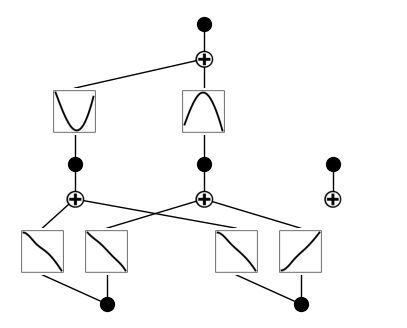

In [85]:
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
# kan =KAN(width=[[len(symbols),0],[2,2],[1,0]], grid=3, k=3, seed=42, device=device)
kan =KAN(width=[2,3,1], grid=3, k=3, seed=seed, device=device)
kanFitLoss1 = kan.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);
kan.plot(beta=10)
# kan.refine(5)
# kanFitLoss2 = kan.fit(dataset1, steps=50, lamb=0.01)
# kan.plot(beta=10)
# kan.refine(7)
# kanFitloss3 = kan.fit(dataset1, steps=50, lamb=0.01)
# kan.plot(beta=10)



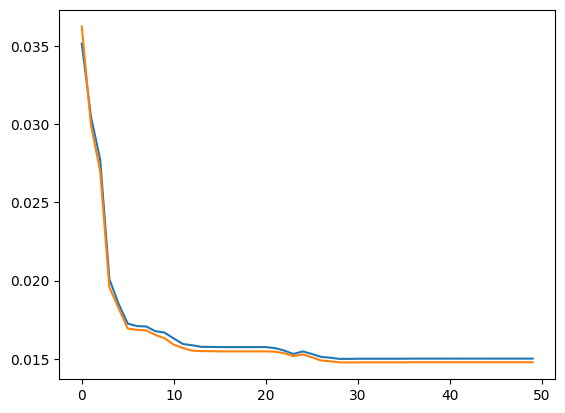

In [86]:
kanLossHistory1test = [x.item() for x in kanFitLoss1['test_loss']]
plt.plot(kanLossHistory1test)
kanLossHistory1train = [x.item() for x in kanFitLoss1['train_loss']]
plt.plot(kanLossHistory1train)
plt.show()
# kanLossHistory2 = [x.item() for x in kanFitLoss2['test_loss']]
# plt.plot(kanLossHistory2)
# kanLossHistory3 = [x.item() for x in kanFitloss3['test_loss']]
# plt.plot(kanLossHistory3)


saving model version 0.2


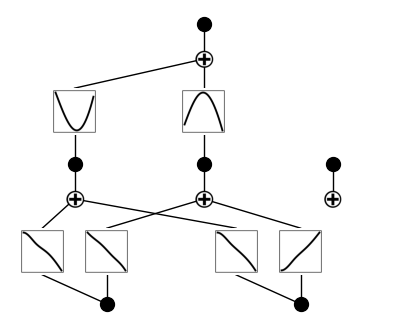

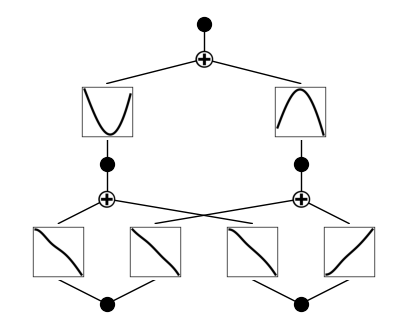

In [87]:
kan.plot(beta=1000)
kan = kan.prune()
kan.plot(beta=1000)

In [78]:
x_draw = X_train.detach().cpu().numpy()
pred = kan(X_train)
y_draw = pred.detach().cpu().numpy()

print(y_draw[:,0])
print(x_draw[:,0])
print(x_draw[:,1])


[ 0.08875869  0.11691929 -0.0415388  ...  0.18110606  0.13207641
 -0.09679353]
[ 0.08898413 -0.1710203   0.87187475 ... -0.8076544  -0.32110533
  0.69168574]
[ 0.8781079  -0.7973837  -0.5761236  ... -0.47219166 -0.685962
 -0.9528958 ]


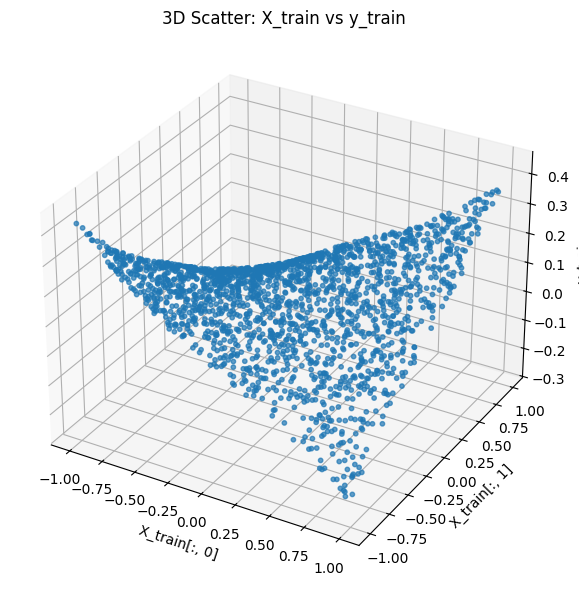

In [79]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_draw[:, 0], x_draw[:, 1], y_draw[:,0], s=10, alpha=0.7)
ax.set_xlabel('X_train[:, 0]')
ax.set_ylabel('X_train[:, 1]')
ax.set_zlabel('y_train')
ax.set_title('3D Scatter: X_train vs y_train')
plt.tight_layout()